# Xây dựng tác tử phản xạ đơn cho tàu đổ bộ Mặt Trăng

Trong ví dụ này, chúng ta sử dụng Gymnasium, một môi trường để huấn luyện tác tử bằng học tăng cường (RL). Tuy nhiên, ở đây chúng ta không dùng RL mà chỉ sử dụng môi trường với một tác tử phản xạ đơn tự xây dựng.

## Cài đặt Gymnasium

Tài liệu Gymnasium có tại https://gymnasium.farama.org/

Các bước:
1. Tạo một thư mục mới, mở bằng VS Code và cài các tiện ích Python cần thiết.
2. Tạo môi trường ảo mới.
3. Trên WSL2, cài `swig` và bộ header C++ của Python nếu cần.
4. Cài Gymnasium cùng các phần mở rộng cần thiết.

In [1]:
# Google Colab hoac neu thieu goi: Bo comment dong %pip ben duoi, chay o nay roi khoi dong lai session.
# %pip install -q "swig>=4,<5" "gymnasium[box2d,classic-control]>=1.0,<2"

Cài thêm các gói để chụp màn hình, nhờ đó hình ảnh môi trường có thể được chuyển thành video nhúng.

Để ghi video, cần cài các gói hệ thống `xvfb` và `ffmpeg`.

## Các gói Python bổ sung để chụp màn hình

In [2]:
# Google Colab hoac neu thieu goi: Bo comment dong %pip ben duoi, chay o nay roi khoi dong lai session.
# %pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

## Môi trường tàu đổ bộ Mặt Trăng

![Hình ảnh tàu đổ bộ Mặt Trăng](https://gymnasium.farama.org/_images/lunar_lander.gif)

Tài liệu môi trường có tại: https://gymnasium.farama.org/environments/box2d/lunar_lander/

* **Thước đo hiệu quả:** Phần thưởng -100 hoặc +100 tương ứng với va chạm hoặc hạ cánh an toàn. Ở đây không dùng phần thưởng trung gian.
* **Môi trường:** Bài toán tối ưu quỹ đạo tên lửa. Tàu cần hạ cánh an toàn trong không gian liên tục, với tọa độ x và y nằm trong [-2.5, 2.5]. Bệ đáp ở tọa độ (0,0).
* **Cơ cấu chấp hành:** Có bốn hành động rời rạc: 0 không làm gì, 1 bật động cơ định hướng trái, 2 bật động cơ chính, 3 bật động cơ định hướng phải.
* **Cảm biến:** Mỗi quan sát là một vectơ 8 chiều gồm tọa độ, vận tốc tuyến tính, góc, vận tốc góc và trạng thái tiếp xúc mặt đất của hai chân.

Có thể truy vấn các khoảng và thiết lập khác nhau của môi trường.

In [3]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2)

In [4]:
def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
   # print(f"Pham vi phan thuong: {env.reward_range}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200


Các môi trường Gymnasium được cài đặt dưới dạng lớp có phương thức `make` để tạo môi trường, `reset` để khởi tạo lại và `step` để thực hiện hành động. Để dùng với hàm tác tử nhận nhận thức và trả về hành động, ta cần viết mã kết nối môi trường với tác tử.

In [5]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Dat lai moi truong de tao quan sat dau tien (dung seed=42 de co ket qua tai hien duoc)
    observation, info = env.reset()

    # Chay mot tap
    for _ in range(max_steps):
        # Goi ham tac tu de chon hanh dong
        action = agent_function(observation)

        if verbose:
            print (f"Obs: {observation} -> Action: {action}")

        # Buoc: thuc thi hanh dong trong moi truong
        observation, reward, terminated, truncated, info = env.step(action)

        # Hien thi moi truong
        if render:
            env.render()

        if terminated:
            if verbose:
                print(f"Final Reward: {reward}")
            break
    
    return reward

## Ví dụ: Tác tử ngẫu nhiên

Tác tử trả về ngẫu nhiên một trong các hành động. Môi trường chấp nhận các số nguyên từ 0 đến 3.

In [6]:
def random_agent_function(observation): 
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

Chạy một tập.

In [7]:
env = gym.make("LunarLander-v3", render_mode="human")

run_episode(random_agent_function, env)

env.close()

Obs: [ 0.    1.41  0.32 -0.04 -0.   -0.07  0.    0.  ] -> Action: 0
Obs: [ 0.01  1.41  0.32 -0.07 -0.01 -0.07  0.    0.  ] -> Action: 1
Obs: [ 0.01  1.41  0.31 -0.09 -0.01 -0.03  0.    0.  ] -> Action: 0
Obs: [ 0.01  1.4   0.31 -0.12 -0.01 -0.03  0.    0.  ] -> Action: 3
Obs: [ 0.02  1.4   0.32 -0.15 -0.01 -0.07  0.    0.  ] -> Action: 1


Obs: [ 0.02  1.4   0.31 -0.17 -0.01 -0.03  0.    0.  ] -> Action: 3
Obs: [ 0.02  1.39  0.32 -0.2  -0.02 -0.07  0.    0.  ] -> Action: 2


Obs: [ 0.03  1.39  0.33 -0.16 -0.02 -0.06  0.    0.  ] -> Action: 3
Obs: [ 0.03  1.38  0.34 -0.19 -0.03 -0.1   0.    0.  ] -> Action: 1
Obs: [ 0.03  1.38  0.33 -0.21 -0.03 -0.06  0.    0.  ] -> Action: 3


Obs: [ 0.03  1.37  0.34 -0.24 -0.03 -0.11  0.    0.  ] -> Action: 0
Obs: [ 0.04  1.37  0.34 -0.27 -0.04 -0.11  0.    0.  ] -> Action: 0
Obs: [ 0.04  1.36  0.34 -0.29 -0.05 -0.11  0.    0.  ] -> Action: 2
Obs: [ 0.05  1.36  0.36 -0.26 -0.05 -0.09  0.    0.  ] -> Action: 2
Obs: [ 0.05  1.35  0.35 -0.22 -0.05 -0.11  0.    0.  ] -> Action: 0


Obs: [ 0.05  1.35  0.35 -0.24 -0.06 -0.11  0.    0.  ] -> Action: 3
Obs: [ 0.06  1.34  0.36 -0.27 -0.07 -0.14  0.    0.  ] -> Action: 2
Obs: [ 0.06  1.33  0.36 -0.25 -0.07 -0.15  0.    0.  ] -> Action: 1
Obs: [ 0.06  1.33  0.35 -0.28 -0.08 -0.12  0.    0.  ] -> Action: 3
Obs: [ 0.07  1.32  0.36 -0.31 -0.09 -0.16  0.    0.  ] -> Action: 0


...

Obs: [ 0.24  0.71  0.48 -1.05 -0.6  -0.15  0.    0.  ] -> Action: 3
Obs: [ 0.25  0.69  0.49 -1.08 -0.61 -0.2   0.    0.  ] -> Action: 3
Obs: [ 0.25  0.66  0.5  -1.11 -0.62 -0.25  0.    0.  ] -> Action: 3
Obs: [ 0.26  0.64  0.51 -1.14 -0.64 -0.29  0.    0.  ] -> Action: 1
Obs: [ 0.26  0.61  0.5  -1.16 -0.65 -0.25  0.    0.  ] -> Action: 1


Obs: [ 0.27  0.59  0.5  -1.18 -0.66 -0.22  0.    0.  ] -> Action: 0
Obs: [ 0.27  0.56  0.5  -1.21 -0.67 -0.22  0.    0.  ] -> Action: 3
Obs: [ 0.28  0.53  0.5  -1.24 -0.68 -0.26  0.    0.  ] -> Action: 0
Obs: [ 0.28  0.5   0.5  -1.27 -0.7  -0.26  0.    0.  ] -> Action: 0
Obs: [ 0.29  0.47  0.5  -1.3  -0.71 -0.26  0.    0.  ] -> Action: 3


Obs: [ 0.29  0.44  0.51 -1.33 -0.72 -0.31  0.    0.  ] -> Action: 0
Obs: [ 0.3   0.41  0.51 -1.35 -0.74 -0.31  0.    0.  ] -> Action: 0
Obs: [ 0.3   0.38  0.51 -1.38 -0.76 -0.31  0.    0.  ] -> Action: 1
Obs: [ 0.31  0.35  0.5  -1.4  -0.77 -0.27  0.    0.  ] -> Action: 1
Obs: [ 0.31  0.32  0.5  -1.43 -0.78 -0.22  0.    0.  ] -> Action: 2
Obs: [ 0.32  0.29  0.53 -1.43 -0.79 -0.22  0.    0.  ] -> Action: 0


Obs: [ 0.32  0.25  0.53 -1.46 -0.8  -0.22  0.    0.  ] -> Action: 3
Obs: [ 0.33  0.22  0.54 -1.49 -0.82 -0.27  0.    0.  ] -> Action: 3
Obs: [ 0.33  0.19  0.54 -1.53 -0.83 -0.33  0.    0.  ] -> Action: 1
Obs: [ 0.34  0.15  0.54 -1.55 -0.85 -0.29  0.    0.  ] -> Action: 1
Obs: [ 0.34  0.12  0.53 -1.57 -0.86 -0.23  0.    0.  ] -> Action: 3


Obs: [ 0.35  0.08  0.54 -1.6  -0.87 -0.29  0.    0.  ] -> Action: 1
Obs: [ 0.35  0.04  0.53 -1.62 -0.88 -0.25  0.    0.  ] -> Action: 2
Obs: [ 0.36  0.01  0.56 -1.63 -0.9  -0.26  0.    0.  ] -> Action: 1
Obs: [ 0.36 -0.02  0.53 -1.46 -0.9  -0.07  1.    0.  ] -> Action: 1
Obs: [ 0.37 -0.06  0.57 -1.47 -0.88  0.39  1.    0.  ] -> Action: 0
Final Reward: -100


Gymnasium hiển thị môi trường bằng phương thức `render()` trên màn hình cục bộ. Với môi trường không có giao diện như Google Colab, đầu ra có thể được ghi lại bằng màn hình ảo dưới dạng video rồi nhúng vào notebook.

Trước hết cần khởi động một màn hình ảo.

Bây giờ có thể dùng wrapper để ghi lại màn hình của môi trường. Các hàm được cung cấp trong [display_record.py].

In [8]:
# Tai ve neu con thieu
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)
    # Dam bao tuong thich da nen tang cho man hinh ao
    if os.path.exists(file):
        with open(file, 'r', encoding='utf-8') as f:
            content = f.read()
        if 'from pyvirtualdisplay import Display' in content and 'try:' not in content:
            content = content.replace(
                "from pyvirtualdisplay import Display\n\nimport os\nos.environ['PYVIRTUALDISPLAY_DISPLAYFD'] = '0'\n\n# Start virtual display\ndisplay = Display(visible=0, size=(640, 480))\ndisplay.start()",
                "try:\n    from pyvirtualdisplay import Display\n    import os\n    os.environ['PYVIRTUALDISPLAY_DISPLAYFD'] = '0'\n    display = Display(visible=0, size=(640, 480))\n    display.start()\nexcept Exception:\n    display = None"
            )
            with open(file, 'w', encoding='utf-8') as f:
                f.write(content)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Agents/")

In [9]:
import gymnasium_display_recorder as dr

env = dr.gym_make('LunarLander-v3', 'LL1', render_fps=30)
run_episode(random_agent_function, env, verbose=False)
env.close()

dr.show('LL1')

C:\Users\dangn\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at C:\Users\dangn\Downloads\lab01 - Agent\lab01 - Agent\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## Tác tử phản xạ đơn

Để mã dễ đọc hơn, ta dùng các kiểu liệt kê cho hành động (số nguyên) và quan sát (chỉ số trong vectơ quan sát).

In [10]:
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7


Xây dựng một tác tử đơn dùng động cơ chính để giảm tốc độ rơi khi tốc độ quá lớn.

In [11]:
def rocket_agent_function(observation):
    """A simple agent function."""

    # Kich hoat dong co chinh neu tau dang roi qua nhanh
    if observation[Obs.VY.value] < -.4:  
        return Act.MAIN.value

    return Act.NO_OP.value 

In [12]:
env = dr.gym_make('LunarLander-v3', 'LL2', render_fps=30)
run_episode(rocket_agent_function, env, verbose = False)
env.close()

dr.show('LL2')

## Đánh giá tác tử

Chạy tác tử trên 100 bài toán và báo cáo phần thưởng trung bình.

In [13]:
def run_episodes(agent_function, env, n=1000):
    """Run multiple episodes with the given agent and return the rewards for each episode."""
    return [run_episode(agent_function, env, verbose=False, render=False) for _ in range(n)]

Chạy thí nghiệm.

In [14]:
env = gym.make("LunarLander-v3", render_mode=None)

# Chay 100 tap theo huong dan trong o markdown truoc
rewards = run_episodes(rocket_agent_function, env, n=100)
print(f"Sample rewards (first 10): {rewards[:10]}")

print(f"Average reward: {np.average(rewards):.2f}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

Sample rewards (first 10): [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100]
Average reward: -98.00
Success rate: 1/100


Hiệu quả này chưa tốt!

## Cài đặt tác tử phản xạ tốt hơn

Xây dựng một tác tử tốt hơn, dùng động cơ trái và phải để hạ cánh an toàn hơn. Kiểm tra hàm tác tử trên 100 bài toán.

In [15]:
def better_reflex_agent_function(observation):
    """
    An advanced proportional-derivative (PD) reflex agent for LunarLander.
    
    Percepts utilized:
    - X, Y: position coordinates
    - VX, VY: linear velocities
    - ANGLE, ANGULAR_VELOCITY: attitude and rotational velocity
    - LEFT_LEG_CONTACT, RIGHT_LEG_CONTACT: ground contact sensors
    
    Strategy:
    1. Steer horizontal attitude towards the landing pad center.
    2. Modulate descent velocity profile based on altitude.
    3. Cushion touchdown immediately upon leg contact.
    """
    s = observation
    
    # Goc nghieng muc tieu dua tren vi tri va van toc ngang
    angle_target = s[Obs.X.value] * 0.5 + s[Obs.VX.value] * 1.0
    angle_target = np.clip(angle_target, -0.4, 0.4)
    
    # Ho so do cao: cho phep bay cao hon khi lech ngang
    hover_target = 0.55 * np.abs(s[Obs.X.value])
    
    # Cac so hang hieu chinh PD
    angle_todo = (angle_target - s[Obs.ANGLE.value]) * 0.5 - s[Obs.ANGULAR_VELOCITY.value] * 1.0
    hover_todo = (hover_target - s[Obs.Y.value]) * 0.5 - s[Obs.VY.value] * 0.5
    
    # Giam chan khi tiep dat
    if s[Obs.LEFT_LEG_CONTACT.value] or s[Obs.RIGHT_LEG_CONTACT.value]:
        angle_todo = 0.0
        hover_todo = -s[Obs.VY.value] * 0.5
        
    # Chon hanh dong dua tren loi uu tien
    if hover_todo > np.abs(angle_todo) and hover_todo > 0.05:
        return Act.MAIN.value
    elif angle_todo < -0.05:
        return Act.RIGHT.value
    elif angle_todo > 0.05:
        return Act.LEFT.value
    return Act.NO_OP.value

# Kiem tra tac tu tren 100 bai toan
print("Testing Better Reflex Agent on 100 problems...")
env = gym.make("LunarLander-v3", render_mode=None)
better_rewards = run_episodes(better_reflex_agent_function, env, n=100)
env.close()

print(f"Average reward: {np.average(better_rewards):.2f}")
print(f"Success rate (safe landing == 100): {np.sum(np.array(better_rewards) == 100)}/{len(better_rewards)} ({np.mean(np.array(better_rewards) == 100)*100:.1f}%)")

Testing Better Reflex Agent on 100 problems...


Average reward: 75.98
Success rate (safe landing == 100): 86/100 (86.0%)


Chạy tác tử được cải thiện và đánh giá kết quả.

In [16]:
# Ghi va hien thi video ha canh an toan voi tac tu phan xa cai tien
env = dr.gym_make('LunarLander-v3', 'LL3', render_fps=30)
run_episode(better_reflex_agent_function, env, verbose=False)
env.close()

dr.show('LL3')

,Agent,Average Final Reward,Safe Landing Rate (%),Crash Rate (%)
0,Random Agent,-100.00000,0.0,100.0
1,Simple Rocket Agent,-98.00000,1.0,99.0
2,Better Reflex Agent (PD Control),75.97893,86.0,10.0


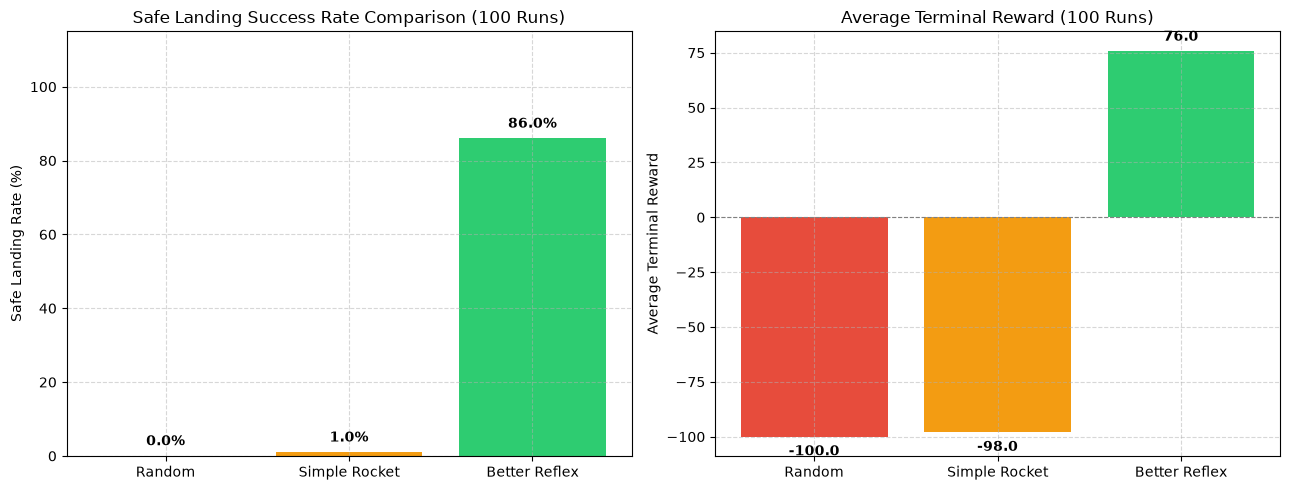

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Danh gia tac tu ngau nhien tren 100 lan chay de so sanh toan dien
env = gym.make("LunarLander-v3", render_mode=None)
random_rewards = run_episodes(random_agent_function, env, n=100)
env.close()

# Bang tom tat hieu suat
perf_df = pd.DataFrame({
    "Agent": ["Random Agent", "Simple Rocket Agent", "Better Reflex Agent (PD Control)"],
    "Average Final Reward": [np.mean(random_rewards), np.mean(rewards), np.mean(better_rewards)],
    "Safe Landing Rate (%)": [
        np.mean(np.array(random_rewards) == 100) * 100,
        np.mean(np.array(rewards) == 100) * 100,
        np.mean(np.array(better_rewards) == 100) * 100
    ],
    "Crash Rate (%)": [
        np.mean(np.array(random_rewards) == -100) * 100,
        np.mean(np.array(rewards) == -100) * 100,
        np.mean(np.array(better_rewards) == -100) * 100
    ]
})

display(perf_df)

# Truc quan hoa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bieu do 1: So sanh ty le thanh cong
agent_names = ["Random", "Simple Rocket", "Better Reflex"]
success_rates = [
    np.mean(np.array(random_rewards) == 100) * 100,
    np.mean(np.array(rewards) == 100) * 100,
    np.mean(np.array(better_rewards) == 100) * 100
]
bars = ax1.bar(agent_names, success_rates, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax1.set_ylabel("Safe Landing Rate (%)")
ax1.set_title("Safe Landing Success Rate Comparison (100 Runs)")
ax1.set_ylim(0, 115)
ax1.grid(True, linestyle="--", alpha=0.5)

for bar in bars:
    y = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, y + 2, f"{y:.1f}%", ha='center', va='bottom', fontweight='bold')

# Bieu do 2: So sanh phan thuong cuoi trung binh
avg_rewards = [np.mean(random_rewards), np.mean(rewards), np.mean(better_rewards)]
bars2 = ax2.bar(agent_names, avg_rewards, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax2.set_ylabel("Average Terminal Reward")
ax2.set_title("Average Terminal Reward (100 Runs)")
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.grid(True, linestyle="--", alpha=0.5)

for bar in bars2:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, y + (3 if y >= 0 else -10), f"{y:.1f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Kết luận

So sánh tác tử ngẫu nhiên, tác tử phản xạ đơn và tác tử phản xạ cải tiến dựa trên phần thưởng trung bình và tỷ lệ hạ cánh thành công. Nêu rõ cách các cảm biến vị trí, vận tốc và góc được dùng để chọn hành động.